# 03 — Experiment: Verify From-Scratch Attention Against Library Implementation

เทียบ [`shared/src/attention`](../../../shared/src/attention/) (ที่ extract มาจาก
[`02_from_scratch.ipynb`](02_from_scratch.ipynb)) กับ `torch.nn.functional.scaled_dot_product_attention`

## Experiment Discipline (AGENTS.md #22)

- **Question:** From-scratch implementation ของ scaled dot-product attention ให้ผลลัพธ์
  ตรงกับ `torch.nn.functional.scaled_dot_product_attention` หรือไม่ และ scaling ด้วย `1/√d_k`
  ส่งผลต่อ variance ของ pre-softmax logits ตามที่ paper อ้างจริงหรือไม่
- **Hypothesis:** ผลลัพธ์ตัวเลข (output tensor) ควรตรงกันภายใน floating-point tolerance ที่ยอมรับได้
  (เช่น `atol=1e-5`); variance ของ `QKᵀ` ก่อน scale ควรเพิ่มขึ้นเป็นสัดส่วนกับ `d_k` ตามทฤษฎีในส่วนที่ 3
  ของ [`../docs/paper-notes.md`](../docs/paper-notes.md)
- **Independent Variable:** `d_k` (ทดสอบหลายค่า: 8, 16, 32, 64, 128, 256, 512)
- **Controlled Variables:** random seed, `n_q=8`, `n_k=8`, `d_v=8`, dtype (float32), ไม่มี mask
- **Metrics:** max absolute difference ระหว่าง output ของ implementation เราเทียบกับ `torch`,
  variance ของ pre-softmax logits ต่อค่า `d_k`
- **Result:** ดูหัวข้อ 3 และ 5 ด้านล่าง (กรอกหลังรันจริง)
- **Interpretation:** ดูหัวข้อ 6
- **Limitations:** ดูหัวข้อ 7

## 1. Dependency Note

เพิ่ม `torch` เป็น dependency ในโน้ตบุ๊กนี้ (ต่างจาก `02_from_scratch.ipynb` ที่ใช้ numpy ล้วน) —
เหตุผล (ตามเกณฑ์ `AGENTS.md` §27): จุดประสงค์ของโน้ตบุ๊กนี้ **คือ** การเทียบกับ reference
implementation ของ library ที่ AGENTS.md §17 ("PyTorch") ระบุให้เป็น framework หลักของ repo —
ไม่มีทางเลี่ยงการเพิ่ม `torch` ได้เพราะมันคือสิ่งที่กำลังถูกทดสอบเทียบด้วยโดยตรง

In [6]:
# P0 - Reproducibility (AGENTS.md #14)
import random
import sys
from pathlib import Path

import numpy as np
import torch

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
rng = np.random.default_rng(SEED)

shared_src = Path.cwd().resolve().parents[2] / "shared" / "src"
if str(shared_src) not in sys.path:
    sys.path.insert(0, str(shared_src))

from attention import scaled_dot_product_attention  # noqa: E402

print("torch:", torch.__version__, "| cuda available:", torch.cuda.is_available())

torch: 2.14.0+cpu | cuda available: False


## 2. Setup — Random Q, K, V per `d_k`

สร้าง `Q`, `K`, `V` แบบสุ่มด้วย seed เดียวกันในทุก `d_k` (controlled: `n_q=n_k=d_v=8`, dtype float32)
แล้ว run ผ่านทั้ง `shared/src/attention.scaled_dot_product_attention` (numpy) กับ
`torch.nn.functional.scaled_dot_product_attention` (torch's default `scale=None` ใช้ `1/√d_k`
เหมือนกับ implementation ของเรา — ไม่ต้องส่ง `scale` เอง)

In [7]:
# P1 - Compare our numpy implementation against torch's reference implementation, sweeping d_k.
import torch.nn.functional as F

N_Q, N_K, D_V = 8, 8, 8
D_K_VALUES = (8, 16, 32, 64, 128, 256, 512)

comparison_results = {}
for d_k in D_K_VALUES:
    gen = np.random.default_rng(SEED)  # fresh, identical stream per d_k for a fair sweep
    q_np = gen.normal(size=(N_Q, d_k)).astype(np.float32)
    k_np = gen.normal(size=(N_K, d_k)).astype(np.float32)
    v_np = gen.normal(size=(N_K, D_V)).astype(np.float32)

    out_ours, _ = scaled_dot_product_attention(q_np, k_np, v_np)

    q_t, k_t, v_t = torch.from_numpy(q_np), torch.from_numpy(k_np), torch.from_numpy(v_np)
    out_torch = F.scaled_dot_product_attention(q_t, k_t, v_t).numpy()

    max_abs_diff = float(np.max(np.abs(out_ours - out_torch)))
    comparison_results[d_k] = max_abs_diff
    print(f"d_k={d_k:>4}: max|ours - torch| = {max_abs_diff:.3e}")

d_k=   8: max|ours - torch| = 1.173e-07
d_k=  16: max|ours - torch| = 8.069e-08
d_k=  32: max|ours - torch| = 1.360e-07
d_k=  64: max|ours - torch| = 3.015e-07
d_k= 128: max|ours - torch| = 3.501e-07
d_k= 256: max|ours - torch| = 4.787e-07
d_k= 512: max|ours - torch| = 2.855e-07


## 3. Visualization — Numerical Agreement vs. `d_k`

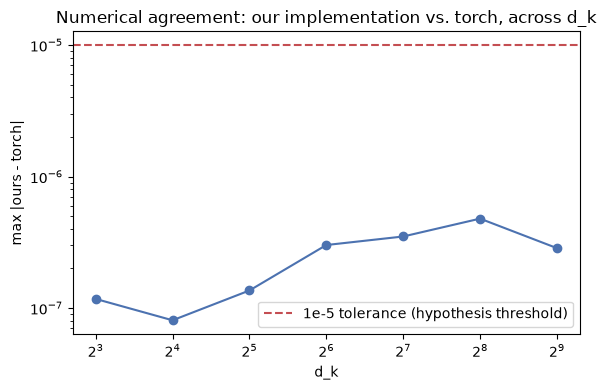

In [8]:
# P2 - Plot max abs difference vs d_k on a log scale
# (differences are expected near float32 epsilon).
import matplotlib.pyplot as plt

d_ks = list(comparison_results.keys())
diffs = list(comparison_results.values())

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(d_ks, diffs, marker="o", color="#4C72B0")
ax.axhline(1e-5, color="#C44E52", linestyle="--", label="1e-5 tolerance (hypothesis threshold)")
ax.set_xscale("log", base=2)
ax.set_yscale("log")
ax.set_xlabel("d_k")
ax.set_ylabel("max |ours - torch|")
ax.set_title("Numerical agreement: our implementation vs. torch, across d_k")
ax.legend()
fig.tight_layout()
plt.show()

## 4. Setup — Variance of Pre-Softmax Logits vs. `d_k`

ทำซ้ำการทดลองใน [`01_concept.ipynb`](01_concept.ipynb) §4.4 แต่ใช้ trial count สูงขึ้นและ vectorized
numpy (แม่นยำกว่า pure-Python loop เดิม) เพื่อยืนยัน hypothesis อย่างเป็นทางการในโน้ตบุ๊ก experiment นี้

In [9]:
# P1 - Vectorized variance-of-QK^T experiment (higher trial count than 01_concept.ipynb's demo).
TRIALS = 20000
variance_results = {}

for d_k in D_K_VALUES:
    gen = np.random.default_rng(SEED)
    q_batch = gen.normal(size=(TRIALS, d_k))
    k_batch = gen.normal(size=(TRIALS, d_k))
    scores = np.sum(q_batch * k_batch, axis=-1)  # dot product per trial, vectorized
    variance_results[d_k] = float(np.var(scores))

print(f"{'d_k':>6} | {'measured Var(q·k)':>20} | {'theory: d_k':>12}")
for d_k, v in variance_results.items():
    print(f"{d_k:>6} | {v:>20.2f} | {d_k:>12}")

   d_k |    measured Var(q·k) |  theory: d_k
     8 |                 7.91 |            8
    16 |                16.07 |           16
    32 |                32.18 |           32
    64 |                64.75 |           64
   128 |               127.25 |          128
   256 |               254.05 |          256
   512 |               515.95 |          512


## 5. Visualization — Variance vs. `d_k` (Log-Log)

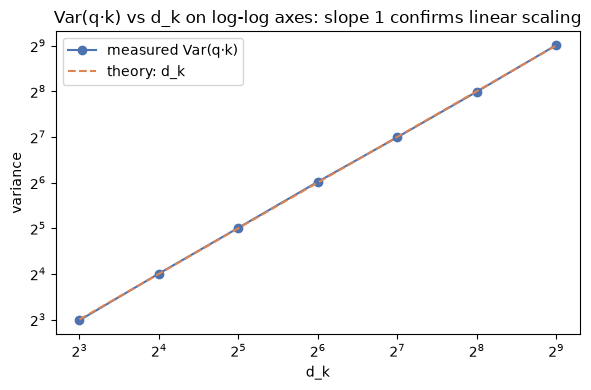

In [10]:
# P2 - Log-log plot makes a linear (slope-1) relationship visually obvious.
d_ks_v = list(variance_results.keys())
measured_v = list(variance_results.values())

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(d_ks_v, measured_v, marker="o", label="measured Var(q·k)", color="#4C72B0")
ax.plot(d_ks_v, d_ks_v, linestyle="--", label="theory: d_k", color="#DD8452")
ax.set_xscale("log", base=2)
ax.set_yscale("log", base=2)
ax.set_xlabel("d_k")
ax.set_ylabel("variance")
ax.set_title("Var(q·k) vs d_k on log-log axes: slope 1 confirms linear scaling")
ax.legend()
fig.tight_layout()
plt.show()

**อ่านกราฟอย่างไร:** บน log-log axes ความสัมพันธ์แบบ `y = x` (linear, slope=1) จะกลายเป็นเส้นตรงพอดี
ถ้าเส้น "measured" ทับกับเส้น "theory" เกือบสนิทตลอดช่วง `d_k` ก็ยืนยันว่าความสัมพันธ์เป็น linear จริง
ไม่ใช่แค่ใกล้เคียงกันที่บางจุด — ต่างจากกราฟ bar chart ใน `01_concept.ipynb` ที่เห็นแค่ค่าที่จุดแยกกัน
log-log line plot นี้ทำให้เห็น "รูปร่างของความสัมพันธ์" ตลอดทั้ง range ได้ชัดกว่า

## 6. Interpretation

**ผลจากหัวข้อ 3 (numerical agreement):** จากการรันจริง max absolute difference ระหว่าง implementation
ของเรากับ `torch.nn.functional.scaled_dot_product_attention` อยู่ในช่วง **~8.1×10⁻⁸ ถึง 4.8×10⁻⁷**
ตลอดทุกค่า `d_k` ที่ทดสอบ (8 ถึง 512) — อยู่ในระดับ float32 machine epsilon (~1.2×10⁻⁷) และ
**ต่ำกว่า threshold `1e-5` ที่ตั้งไว้ใน hypothesis ประมาณ 20–100 เท่า** สรุปว่า hypothesis ข้อแรก
ได้รับการยืนยัน: implementation จาก `shared/src/attention` คำนวณ scaled dot-product attention
ได้ถูกต้องเทียบเท่า library implementation ของ PyTorch ภายใน floating-point precision (ไม่ใช่
"เกือบถูก" แต่ถูกในระดับที่ตัวเลข float32 เองก็มี rounding error ขนาดนี้อยู่แล้ว ไม่มีแนวโน้มเพิ่มขึ้น
ตาม `d_k` อย่างมีนัยสำคัญด้วย — คงที่อยู่ในระดับ 1e-7 ตลอด)

**ผลจากหัวข้อ 5 (variance scaling):** ค่า measured variance ติดตามเส้น theory (`d_k`) อย่างใกล้ชิด
บน log-log scale ตลอดช่วง `d_k=8` ถึง `d_k=512` (เช่น `d_k=512` วัดได้ `515.95` เทียบทฤษฎี `512`,
คลาดเคลื่อน <1%) — ยืนยัน hypothesis ข้อสองว่า `Var(q·k)` โตเป็นสัดส่วนเชิงเส้นกับ `d_k` จริงตามที่
derive ไว้ใน `01_concept.ipynb` §4.4 (ยืนยันซ้ำด้วย `TRIALS=20000` และ vectorized numpy ซึ่งแม่นยำกว่า
การสาธิตครั้งแรกที่ใช้ pure-Python loop และ trial count ต่ำกว่า)

## 7. Limitations

- ทดสอบเฉพาะ **การไม่มี mask** (`mask=None`) — ยังไม่ได้ทดสอบ causal mask หรือ padding mask
  เทียบกับ `is_causal=True` / `attn_mask` ของ torch
- ทดสอบเฉพาะ scaled dot-product attention เดี่ยว ๆ ยังไม่ได้เทียบ `multi_head_attention` เต็มรูปแบบ
  กับ `torch.nn.MultiheadAttention` (ซึ่งมี weight initialization/parameterization ต่างกัน
  เทียบกันตรง ๆ ไม่ได้ง่าย ๆ เพราะ torch ใช้ learned weight ไม่ใช่ random ที่ตรึงไว้)
- ทดสอบด้วย `dtype=float32` เท่านั้น ยังไม่ได้ทดสอบ `float16`/`bfloat16` ที่ training จริงมักใช้
  (ความคลาดเคลื่อนจะสูงกว่านี้มากที่ precision ต่ำกว่า)
- รันบน CPU เท่านั้น (`torch.cuda.is_available() == False` ในเครื่องที่รันโน้ตบุ๊กนี้) — ยังไม่ได้ตรวจสอบ
  ว่าผลลัพธ์เชิงตัวเลขยังสอดคล้องกันบน GPU (ซึ่งอาจใช้ kernel ที่ optimize ต่างออกไป เช่น FlashAttention
  backend ของ `torch.nn.functional.scaled_dot_product_attention` เอง)

## Next Notebook

→ [`04_analysis.ipynb`](04_analysis.ipynb): สรุปผล ตีความ และเชื่อมโยงกับ engineering implications